In [36]:
# LAB ASSIGNMENT - 5
# MULTICLASS CLASSIFICATION
# DATASET: DERMATOLOGY

# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

In [37]:
print("UPLOAD YOUR DERMATOLOGY ZIP FILE")
uploaded = files.upload()
# Get uploaded ZIP filename
zip_file = list(uploaded.keys())[0]
# Extract ZIP
extract_folder = "dermatology_data"
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)
print("\nZIP FILE EXTRACTED SUCCESSFULLY!")

UPLOAD YOUR DERMATOLOGY ZIP FILE


Saving archive (4).zip to archive (4) (4).zip

ZIP FILE EXTRACTED SUCCESSFULLY!


In [38]:
data_file = None
for root, folders, filenames in os.walk(extract_folder):
    for filename in filenames:
        # Look for common Dermatology dataset files
        if filename.lower().endswith((".data", ".csv", ".txt")):
            # Ignore metadata/readme files
            if "name" not in filename.lower() and "readme" not in filename.lower():
                data_file = os.path.join(root, filename)
                break
    if data_file is not None:
        break
if data_file is None:
    print("\nCould not automatically find the dataset file.")
    print("Files found:")
    for root, folders, filenames in os.walk(extract_folder):
        for filename in filenames:
            print(os.path.join(root, filename))
    raise FileNotFoundError(
        "Please check the dataset filename."
    )
print("Dataset file found:")
print(data_file)

Dataset file found:
dermatology_data/dermatology_database_1.csv


In [39]:
# Dermatology dataset normally has no header
df = pd.read_csv(
    data_file,
    header=None,
    na_values=["?", "NA", "N/A", ""]
)
print("Dataset loaded successfully!")
print("\nDataset Shape:")
print(df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset loaded successfully!

Dataset Shape:
(367, 35)

First 5 Rows:
         0        1                 2        3                   4   \
0  erythema  scaling  definite_borders  itching  koebner_phenomenon   
1         2        2                 0        3                   0   
2         3        3                 3        2                   1   
3         2        1                 2        3                   1   
4         2        2                 2        0                   0   

                  5                   6                         7   \
0  polygonal_papules  follicular_papules  oral_mucosal_involvement   
1                  0                   0                         0   
2                  0                   0                         0   
3                  3                   0                         3   
4                  0                   0                         0   

                           8                  9   ...  \
0  knee_and_elbow_involve

In [40]:
# COLUMN NAMES
# Dermatology dataset = 34 features + 1 target
df.columns = (
    [f"Feature_{i}" for i in range(1, df.shape[1])]
    + ["Class"]
)
print("Column Names:")
print(df.columns)

Column Names:
Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5',
       'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10',
       'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15',
       'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20',
       'Feature_21', 'Feature_22', 'Feature_23', 'Feature_24', 'Feature_25',
       'Feature_26', 'Feature_27', 'Feature_28', 'Feature_29', 'Feature_30',
       'Feature_31', 'Feature_32', 'Feature_33', 'Feature_34', 'Class'],
      dtype='object')


In [41]:
# CONVERT DATA TO NUMERIC
df = df.apply(pd.to_numeric, errors="coerce")
# MISSING VALUES
print("MISSING VALUES")
print(df.isnull().sum())
missing_total = df.isnull().sum().sum()
print("\nTotal Missing Values:", missing_total)

MISSING VALUES
Feature_1     1
Feature_2     1
Feature_3     1
Feature_4     1
Feature_5     1
Feature_6     1
Feature_7     1
Feature_8     1
Feature_9     1
Feature_10    1
Feature_11    1
Feature_12    1
Feature_13    1
Feature_14    1
Feature_15    1
Feature_16    1
Feature_17    1
Feature_18    1
Feature_19    1
Feature_20    1
Feature_21    1
Feature_22    1
Feature_23    1
Feature_24    1
Feature_25    1
Feature_26    1
Feature_27    1
Feature_28    1
Feature_29    1
Feature_30    1
Feature_31    1
Feature_32    1
Feature_33    1
Feature_34    9
Class         1
dtype: int64

Total Missing Values: 43


In [42]:
# Handle missing values using median
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(
            df[column].median()
        )
print("\nMissing values after handling:")
print(df.isnull().sum().sum())


Missing values after handling:
0


In [43]:
# DUPLICATES
print("DUPLICATES")
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

DUPLICATES
Duplicate rows: 0
Shape after removing duplicates: (367, 35)


In [44]:
# SUMMARY STATISTICS
print("SUMMARY STATISTICS")
print(df.describe())

SUMMARY STATISTICS
        Feature_1  Feature_2   Feature_3   Feature_4   Feature_5   Feature_6  \
count  367.000000  367.00000  367.000000  367.000000  367.000000  367.000000   
mean     2.068120    1.79564    1.550409    1.365123    0.632153    0.446866   
std      0.663854    0.70065    0.906590    1.136904    0.907378    0.956305   
min      0.000000    0.00000    0.000000    0.000000    0.000000    0.000000   
25%      2.000000    1.00000    1.000000    0.000000    0.000000    0.000000   
50%      2.000000    2.00000    2.000000    1.000000    0.000000    0.000000   
75%      2.000000    2.00000    2.000000    2.000000    1.000000    0.000000   
max      3.000000    3.00000    3.000000    3.000000    3.000000    3.000000   

        Feature_7   Feature_8   Feature_9  Feature_10  ...  Feature_26  \
count  367.000000  367.000000  367.000000  367.000000  ...  367.000000   
mean     0.166213    0.376022    0.613079    0.517711  ...    0.463215   
std      0.569874    0.833239    0.982

In [45]:
# MEAN
print("MEAN:")
print(df.mean())

MEAN:
Feature_1      2.068120
Feature_2      1.795640
Feature_3      1.550409
Feature_4      1.365123
Feature_5      0.632153
Feature_6      0.446866
Feature_7      0.166213
Feature_8      0.376022
Feature_9      0.613079
Feature_10     0.517711
Feature_11     0.125341
Feature_12     0.403270
Feature_13     0.138965
Feature_14     0.544959
Feature_15     0.335150
Feature_16     1.370572
Feature_17     1.956403
Feature_18     0.525886
Feature_19     1.288828
Feature_20     0.662125
Feature_21     0.989101
Feature_22     0.632153
Feature_23     0.294278
Feature_24     0.362398
Feature_25     0.392371
Feature_26     0.463215
Feature_27     0.455041
Feature_28     0.950954
Feature_29     0.452316
Feature_30     0.103542
Feature_31     0.114441
Feature_32     1.866485
Feature_33     0.553134
Feature_34    36.264305
Class          2.803815
dtype: float64


In [46]:
# MEDIAN
print("MEDIAN:")
print(df.median())

MEDIAN:
Feature_1      2.0
Feature_2      2.0
Feature_3      2.0
Feature_4      1.0
Feature_5      0.0
Feature_6      0.0
Feature_7      0.0
Feature_8      0.0
Feature_9      0.0
Feature_10     0.0
Feature_11     0.0
Feature_12     0.0
Feature_13     0.0
Feature_14     0.0
Feature_15     0.0
Feature_16     2.0
Feature_17     2.0
Feature_18     0.0
Feature_19     1.0
Feature_20     0.0
Feature_21     0.0
Feature_22     0.0
Feature_23     0.0
Feature_24     0.0
Feature_25     0.0
Feature_26     0.0
Feature_27     0.0
Feature_28     0.0
Feature_29     0.0
Feature_30     0.0
Feature_31     0.0
Feature_32     2.0
Feature_33     0.0
Feature_34    35.0
Class          3.0
dtype: float64


In [47]:
# STANDARD DEVIATION
print("\nSTANDARD DEVIATION:")
print(df.std())


STANDARD DEVIATION:
Feature_1      0.663854
Feature_2      0.700650
Feature_3      0.906590
Feature_4      1.136904
Feature_5      0.907378
Feature_6      0.956305
Feature_7      0.569874
Feature_8      0.833239
Feature_9      0.982159
Feature_10     0.904806
Feature_11     0.331557
Feature_12     0.868885
Feature_13     0.411291
Feature_14     0.814835
Feature_15     0.852153
Feature_16     1.103400
Feature_17     0.711541
Feature_18     0.756581
Feature_19     0.916432
Feature_20     1.055953
Feature_21     1.161726
Feature_22     1.034039
Feature_23     0.669838
Feature_24     0.758920
Feature_25     0.848494
Feature_26     0.864057
Feature_27     0.953865
Feature_28     1.129724
Feature_29     0.953732
Feature_30     0.449849
Feature_31     0.488092
Feature_32     0.725149
Feature_33     1.104776
Feature_34    15.136299
Class          1.595652
dtype: float64


In [48]:
# OUTLIER DETECTION
print("OUTLIER DETECTION")
features_only = df.drop("Class", axis=1)
Q1 = features_only.quantile(0.25)
Q3 = features_only.quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (
    (features_only < (Q1 - 1.5 * IQR)) |
    (features_only > (Q3 + 1.5 * IQR))
)
outlier_count = outlier_condition.sum()
print("Outliers in each feature:")
print(outlier_count)

OUTLIER DETECTION
Outliers in each feature:
Feature_1     151
Feature_2       0
Feature_3       0
Feature_4       0
Feature_5      18
Feature_6      69
Feature_7      33
Feature_8      67
Feature_9      23
Feature_10     16
Feature_11     46
Feature_12     70
Feature_13     42
Feature_14      7
Feature_15     54
Feature_16      0
Feature_17    156
Feature_18      5
Feature_19      0
Feature_20      0
Feature_21      0
Feature_22     31
Feature_23     70
Feature_24     80
Feature_25     71
Feature_26     14
Feature_27     72
Feature_28      0
Feature_29     72
Feature_30     22
Feature_31     21
Feature_32      0
Feature_33     77
Feature_34      0
dtype: int64


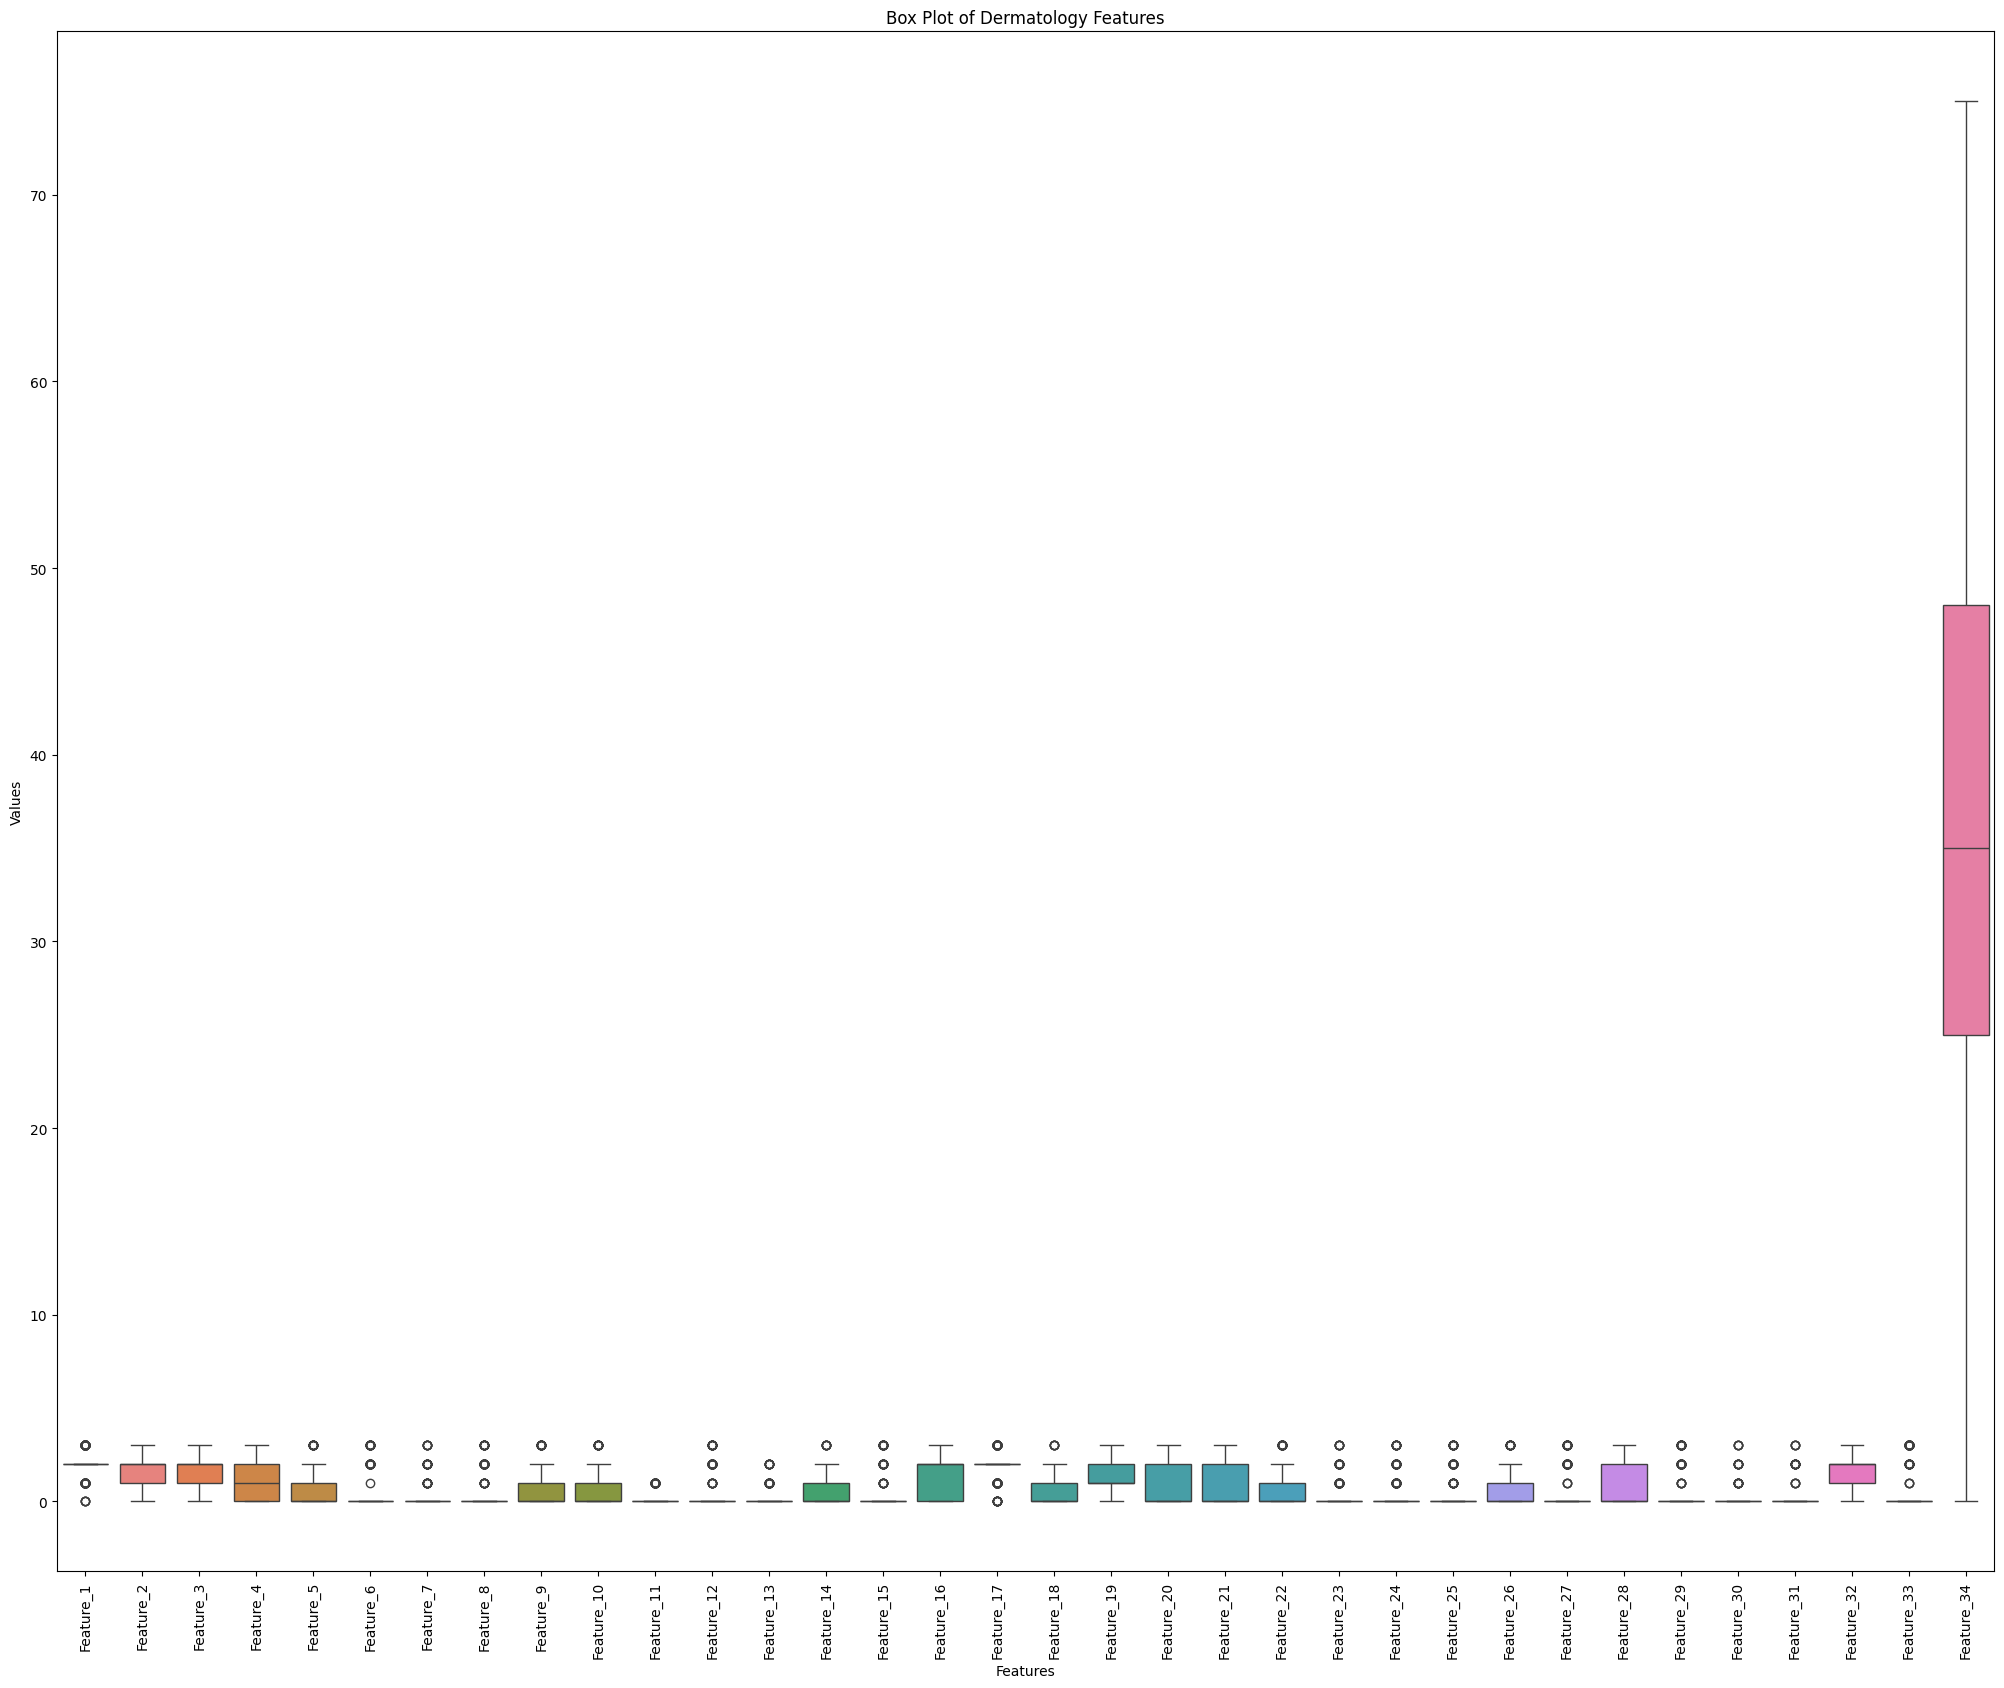

In [49]:
# BOX PLOT
plt.figure(figsize=(25, 20))
sns.boxplot(data=features_only)
plt.title("Box Plot of Dermatology Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=90)
plt.show()

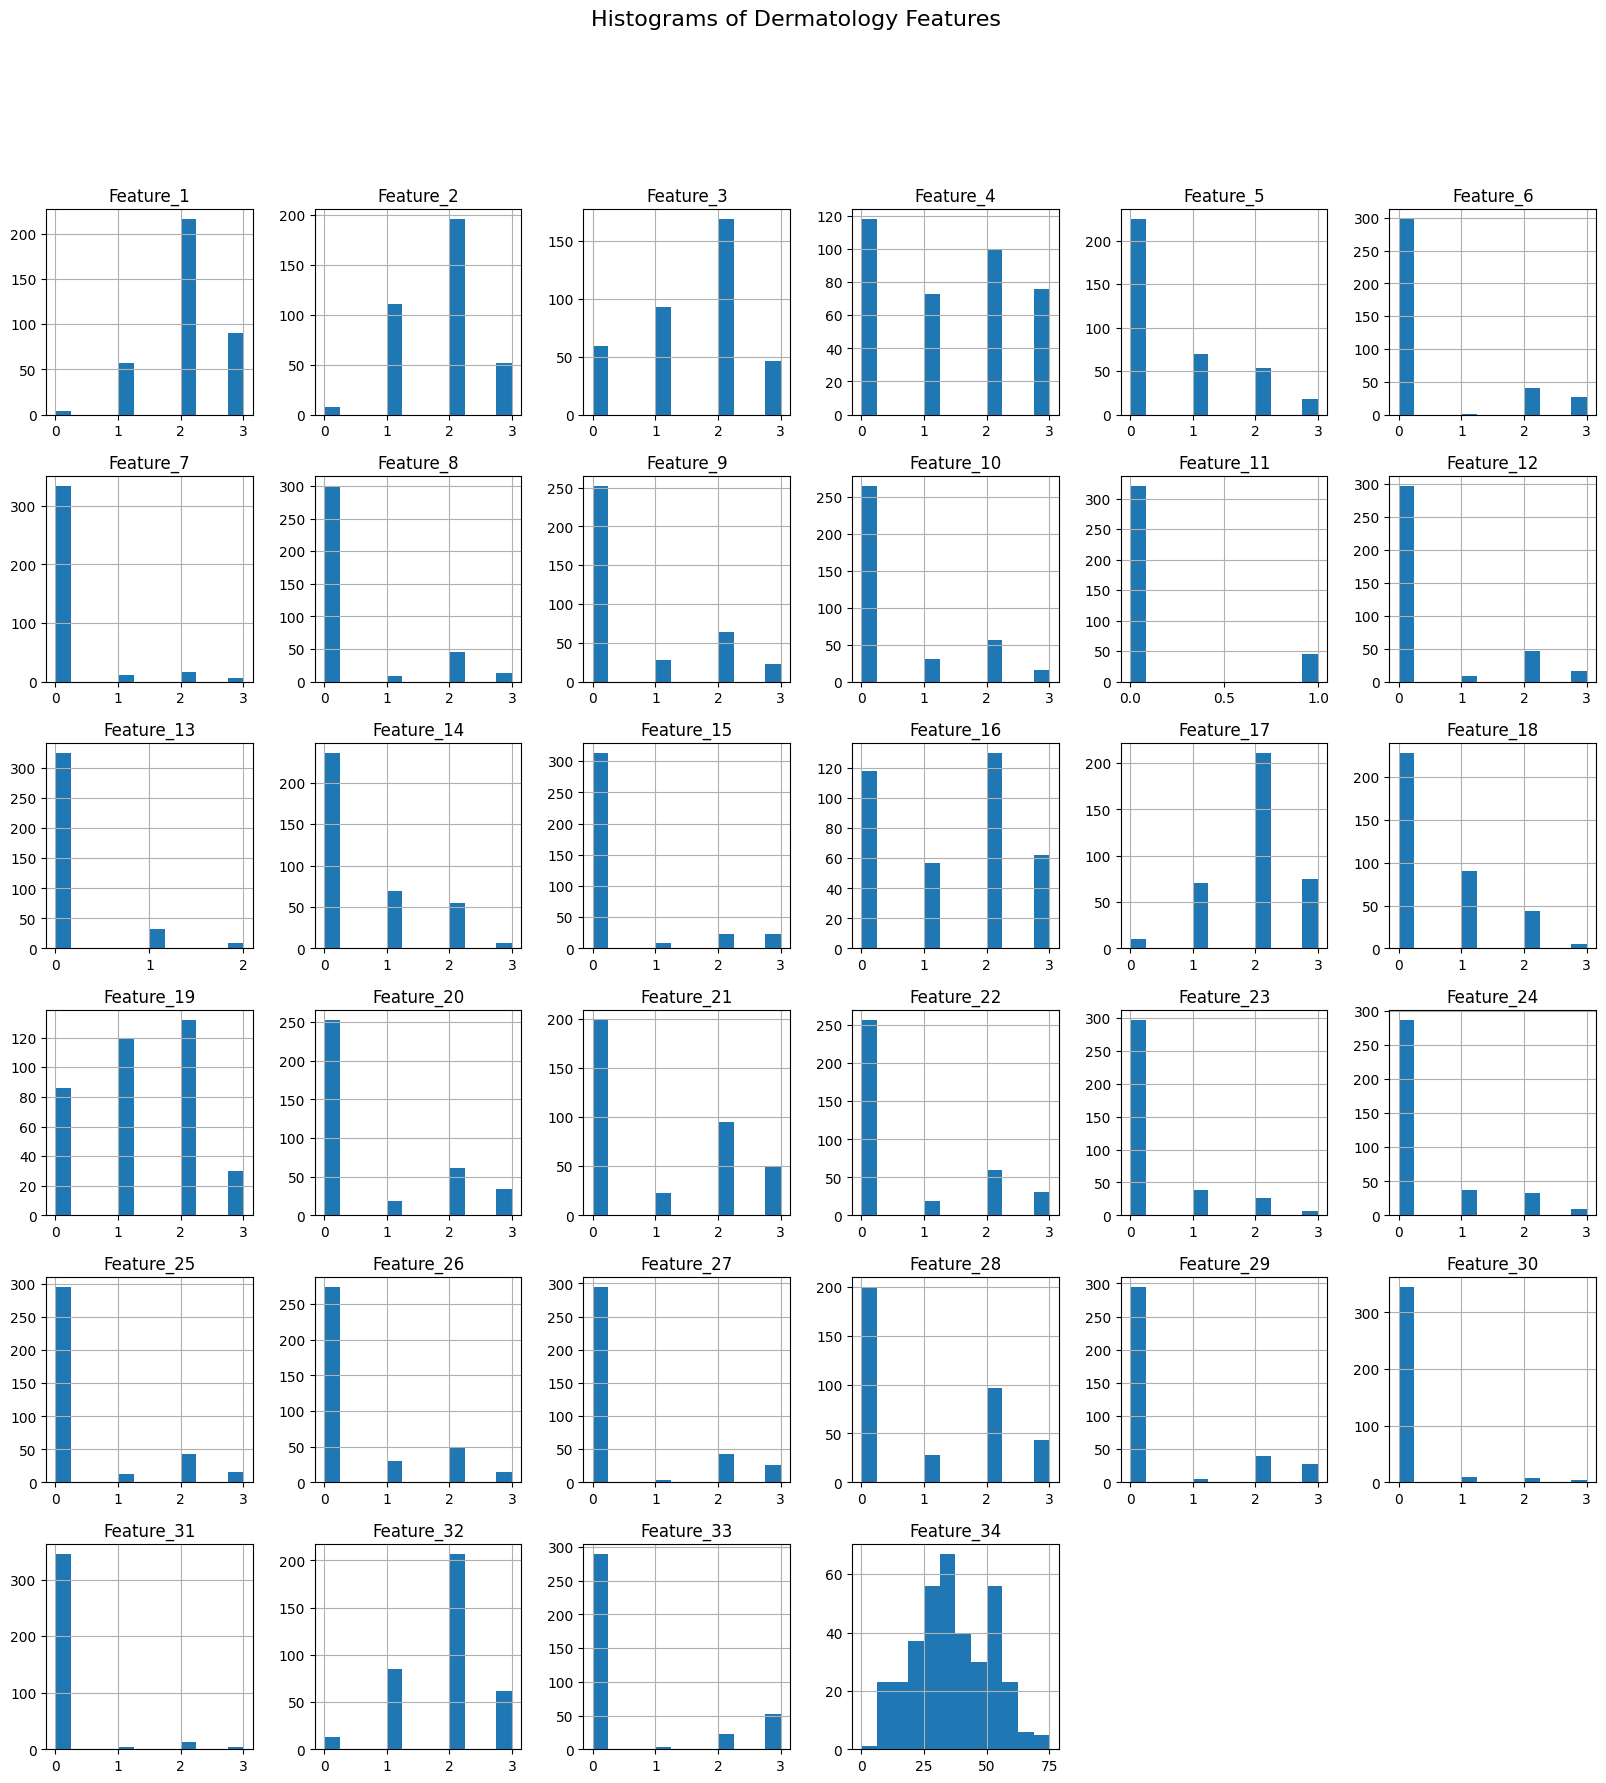

In [50]:
# HISTOGRAMS
features_only.hist(
    figsize=(20,20),
    bins=12
)
plt.suptitle(
    "Histograms of Dermatology Features",
    fontsize=16
)
plt.show()

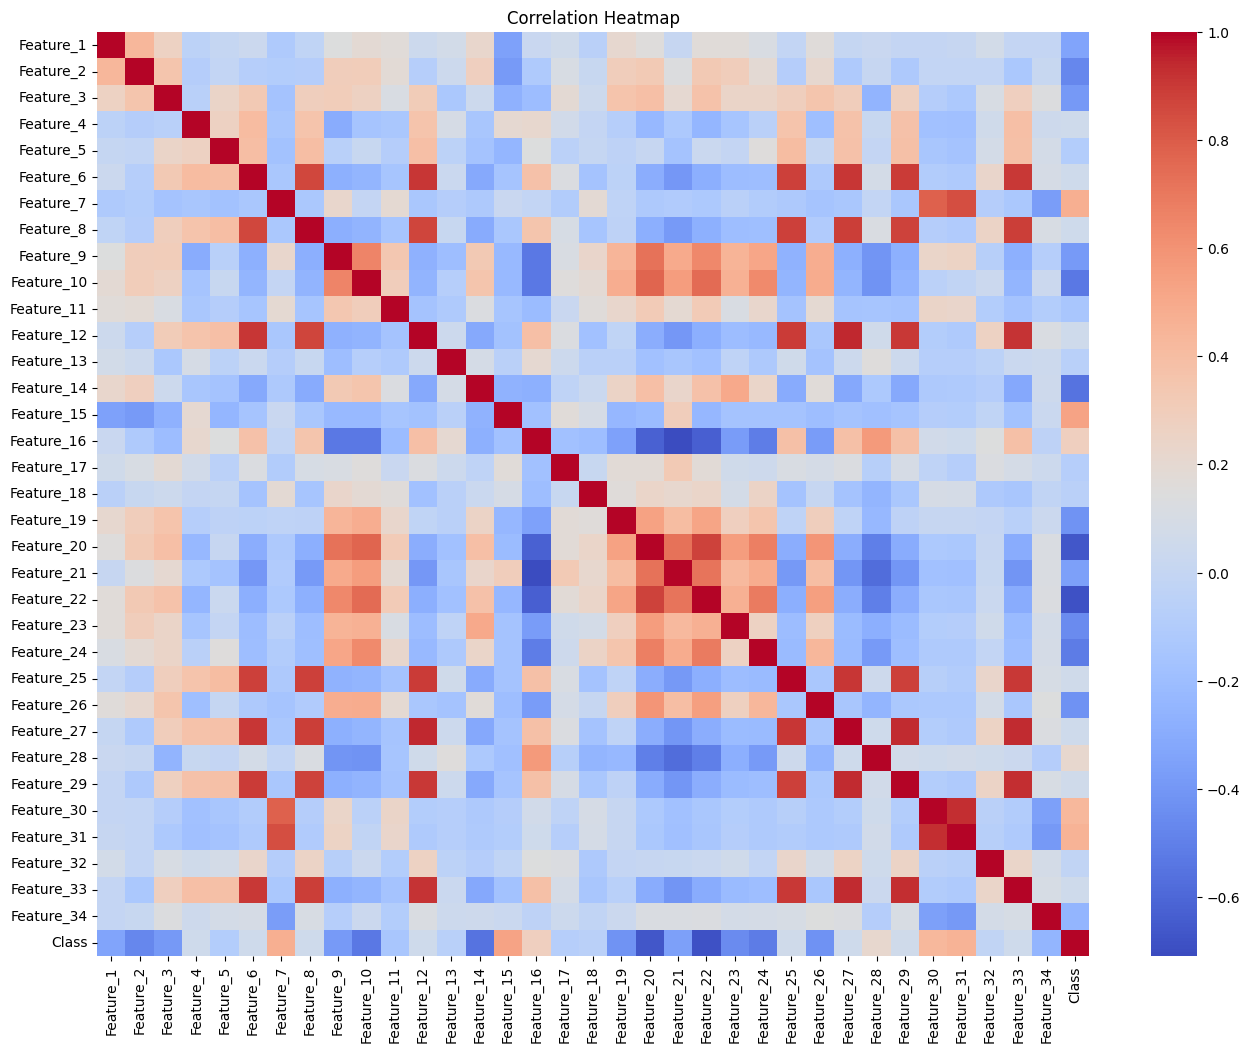

In [51]:
# CORRELATION HEATMAP
plt.figure(figsize=(16, 12))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

CLASS DISTRIBUTION
Class
1.0    112
2.0     61
3.0     73
4.0     49
5.0     52
6.0     20
Name: count, dtype: int64


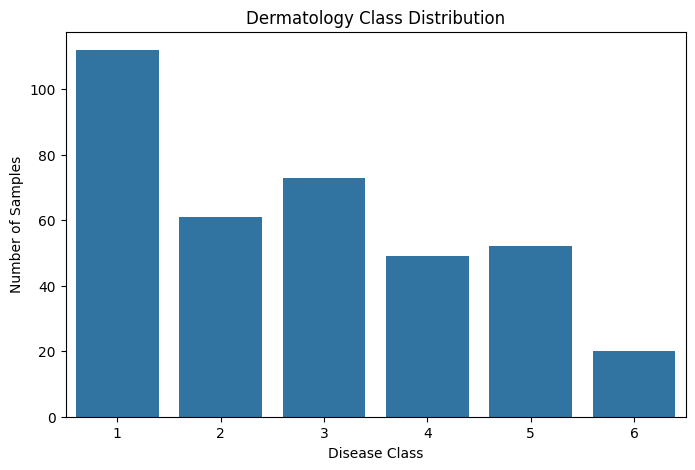


Class Distribution Percentage:
Class
1.0    30.52
2.0    16.62
3.0    19.89
4.0    13.35
5.0    14.17
6.0     5.45
Name: proportion, dtype: float64


In [52]:
# CLASS DISTRIBUTION
print("CLASS DISTRIBUTION")
class_counts = df["Class"].value_counts().sort_index()
print(class_counts)
# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    x=df["Class"].astype(int)
)
plt.title("Dermatology Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.show()
# Percentage distribution
print("\nClass Distribution Percentage:")
class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)
print(class_percentage.round(2))

In [53]:
# TASK 2: DATA PREPROCESSING
print("TASK 2: DATA PREPROCESSING")
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"].astype(int)
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

TASK 2: DATA PREPROCESSING

Features shape: (367, 34)
Target shape: (367,)


In [54]:
# TRAIN TEST SPLIT - 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (293, 34)
Testing data: (74, 34)


In [55]:
# STANDARDIZATION
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Features standardized successfully!")

Features standardized successfully!


In [56]:
# TASK 3: MODEL TRAINING
print("TASK 3: MODEL TRAINING")
# Create models
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=2000),
    "KNN":
        KNeighborsClassifier(n_neighbors=5),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

TASK 3: MODEL TRAINING


In [57]:
# TRAIN AND EVALUATE MODELS
results = []
all_models = {}
for name, model in models.items():
    print(name)
    # Train model
    model.fit(X_train, y_train)
    all_models[name] = model
    # Predictions
    y_pred = model.predict(X_test)
    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    print("\nAccuracy:",
          round(accuracy * 100, 2), "%")
    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )
    # Probability prediction
    y_probability = model.predict_proba(X_test)
    # Multiclass AUC
    y_test_binary = label_binarize(
        y_test,
        classes=np.sort(y.unique())
    )
    auc_score = roc_auc_score(
        y_test_binary,
        y_probability,
        multi_class="ovr"
    )
    print(
        "Overall Multiclass AUC:",
        round(auc_score, 3)
    )
    # Save results
    results.append([
        name,
        accuracy,
        auc_score
    ])

Logistic Regression

Accuracy: 94.59 %

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.87      0.93        15
           4       0.71      1.00      0.83        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.95        74
   macro avg       0.95      0.95      0.95        74
weighted avg       0.96      0.95      0.95        74

Overall Multiclass AUC: 0.999
KNN

Accuracy: 89.19 %

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.80      0.67      0.73        12
           3       1.00      0.87      0.93        15
           4       0.60      0.90      0.72        10
           5       1.00      1.00      1.00   

In [58]:
# MODEL COMPARISON
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "AUC"
    ]
)
comparison_df["Accuracy (%)"] = (
    comparison_df["Accuracy"] * 100
).round(2)
comparison_df["AUC"] = (
    comparison_df["AUC"].round(3)
)
print("FINAL MODEL COMPARISON")
print(
    comparison_df[
        ["Model", "Accuracy (%)", "AUC"]
    ].to_string(index=False)
)

FINAL MODEL COMPARISON
              Model  Accuracy (%)   AUC
Logistic Regression         94.59 0.999
                KNN         89.19 0.981
      Random Forest         95.95 0.996
                SVM         95.95 0.992


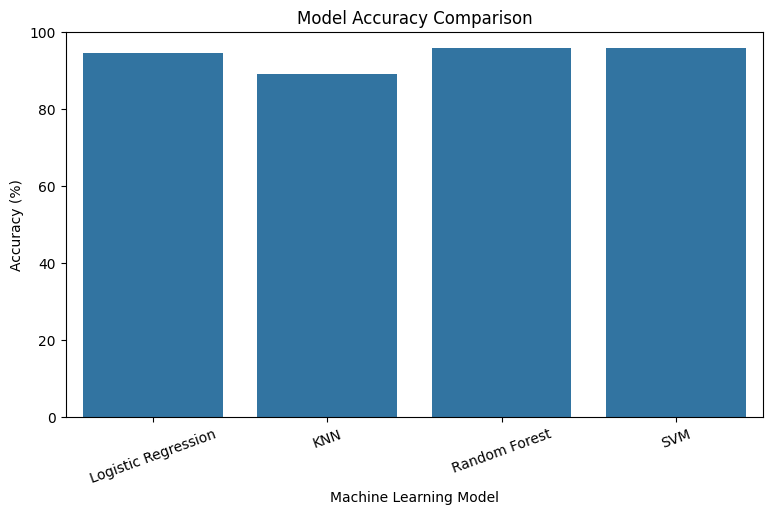

In [59]:
# ACCURACY COMPARISON GRAPH
plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy (%)"
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

CONFUSION MATRICES


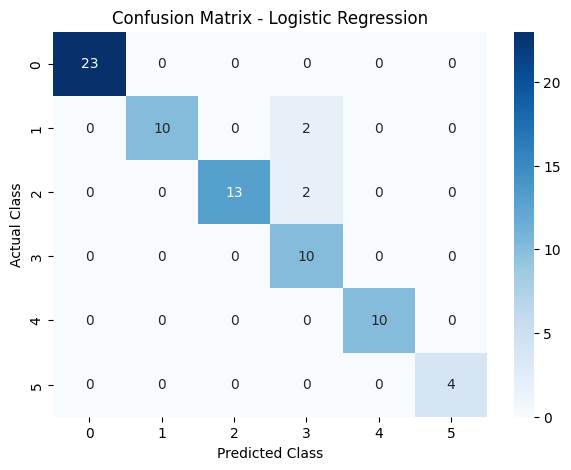

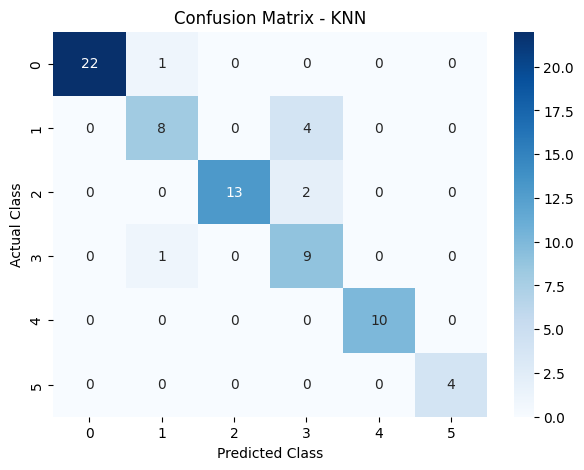

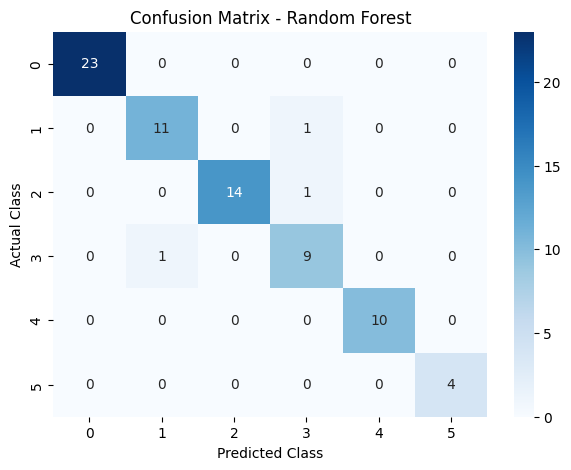

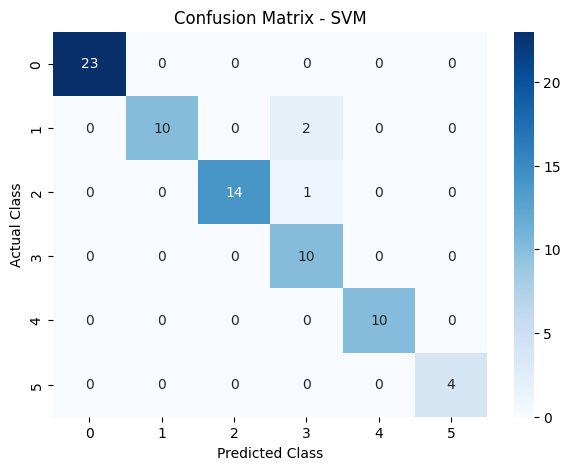

In [60]:
# CONFUSION MATRICES
print("CONFUSION MATRICES")
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(
        y_test,
        y_pred
    )
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(
        "Confusion Matrix - " + name
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

ROC CURVES AND AUC


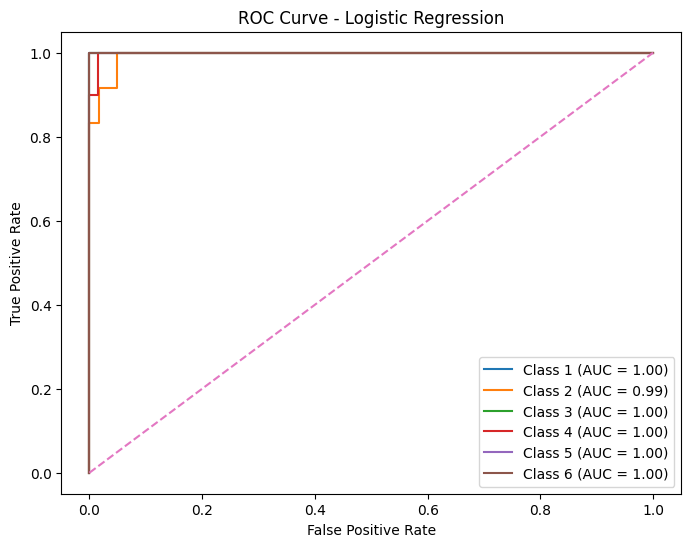

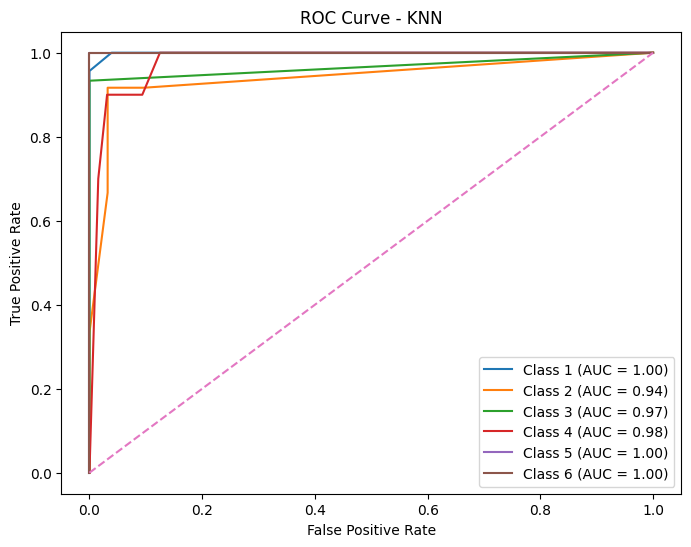

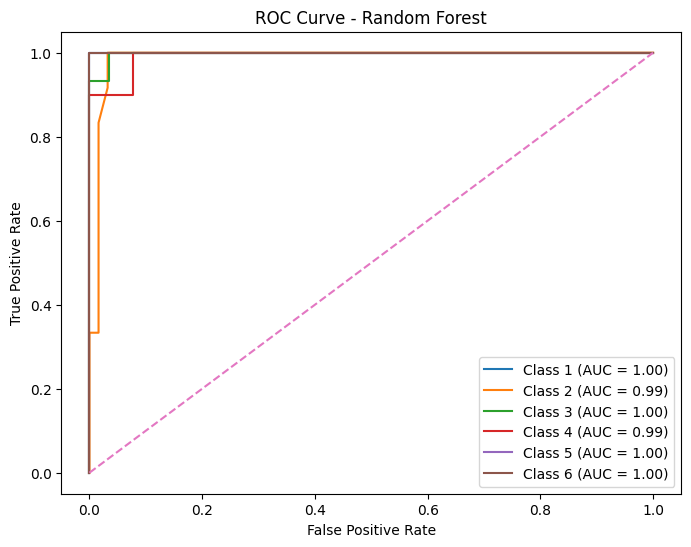

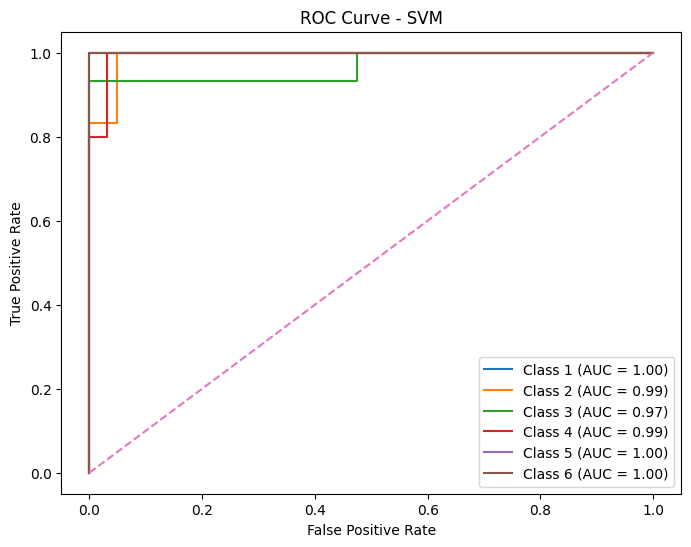

In [61]:
# ROC CURVES AND AUC
print("ROC CURVES AND AUC")
classes = np.sort(y.unique())
y_test_binary = label_binarize(
    y_test,
    classes=classes
)
for name, model in all_models.items():
    y_probability = model.predict_proba(
        X_test
    )
    plt.figure(figsize=(8, 6))
    # ROC curve for every class
    for i, class_value in enumerate(classes):
        fpr, tpr, thresholds = roc_curve(
            y_test_binary[:, i],
            y_probability[:, i]
        )
        roc_auc = auc(
            fpr,
            tpr
        )
        plt.plot(
            fpr,
            tpr,
            label=
            f"Class {class_value} "
            f"(AUC = {roc_auc:.2f})"
        )
    # Random classifier line
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )
    plt.xlabel(
        "False Positive Rate"
    )
    plt.ylabel(
        "True Positive Rate"
    )
    plt.title(
        "ROC Curve - " + name
    )
    plt.legend()
    plt.show()